In [1]:
import torch
from torch import Tensor
from torchmetrics.classification import (
    ConfusionMatrix,
    F1Score,
    Precision,
    Recall,
    Specificity,
    PrecisionRecallCurve,
    AveragePrecision,
)
from torchmetrics import MetricCollection

from monai.metrics import DiceMetric

from functools import partial
from pprint import pprint
from typing import Any, Dict, List, Union, Literal, Final, Tuple

from src.metrics.metric_wrappers import MultitaskWrapper, ClasswiseWrapper, DiceMetricWrapper
from src.metrics.multi_res_metrics_new import SegmentationMetrics, BinaryPatchClassifyMetrics, MultiLabelPatchClassifyMetrics
import time


/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def complement_randomly_chosen_elements(y_true, frac=0.3):
    assert ((y_true >= 0) & (y_true <= 1)).all()
    #create y_pred by randomly swapping x% of y_true values
    y_pred = y_true.detach().clone()
    num_elements = y_true.numel()
    num_samples = int(num_elements * frac)  # x% of the elements
    #swap randomly chosen indices
    idxs = torch.randperm(num_elements)[:num_samples]
    idxs = torch.unravel_index(idxs,shape=y_true.shape)
    y_pred[idxs] = 1 - y_pred[idxs]
    return y_pred

def _keys2str(
        preds:Dict[str, Tensor],
        trues:Union[Tensor, Dict[str, Tensor]]
    )->Tuple:
    preds = {f'{k}':v for k, v in preds.items()}
    if isinstance(trues, dict):
        trues = {f'{k}':v for k, v in trues.items()}
    return (preds, trues)

def _print(text, x, n=30):
    print("-"*n)
    print(text)
    print("-"*n)
    pprint(x, sort_dicts=False)
    print('\n')

## Testing Segmentation Metrics
- `Compare created SegmentationMetrics with MONAI DiceMetric`

#### Create dummy inputs


In [3]:
#create dummy inputs
def create_segment_preds_and_target(**kwargs):
    patch_sizes = kwargs.get('patch_sizes', [8, 16, 32])
    fracs = kwargs.get('fracs', {8: 0.1, 16: 0.2, 32: 0.3})
    im_size = kwargs.get('im_size', 8)
    n_channels = kwargs.get('n_channels', 3)
    batch_size = kwargs.get('batch_size', 100)
    thresh = kwargs.get('thresh', 0.6)
    target = torch.rand((batch_size, n_channels, im_size, im_size, im_size))
    preds = {}
    patch_sizes = sorted(patch_sizes)
    for patch_size in patch_sizes:
        pred = complement_randomly_chosen_elements(target, frac=fracs[patch_size])
        preds[patch_size] = pred
    pred_mean = torch.stack(list(preds.values())).mean(dim=0)
    preds['mean'] = pred_mean
    target = target.gt(thresh)
    return preds, target

In [4]:
preds, target = create_segment_preds_and_target(patch_sizes=[16, 8, 32])
print('preds', {k:v.shape for k,v in preds.items()})
print('target', target.shape)

preds {8: torch.Size([100, 3, 8, 8, 8]), 16: torch.Size([100, 3, 8, 8, 8]), 32: torch.Size([100, 3, 8, 8, 8]), 'mean': torch.Size([100, 3, 8, 8, 8])}
target torch.Size([100, 3, 8, 8, 8])


### Log MONAI DiceMetric

In [5]:
start_time = time.time()
dice = DiceMetric(include_background=True, reduction="mean_batch", ignore_empty=False)

dices = []
for patch_size, pred in preds.items():
    dice(pred.gt(0.5), target)
    val = dice.aggregate()
    val_mean = val.mean().view(1)
    print(f'MONAI Dice on {patch_size} = {torch.cat([val, val_mean])}') 
    dices.append(val_mean)
    dice.reset()

print(f'Mean dice={torch.cat(dices).mean()}')
print('Directly took ', time.time()-start_time)

MONAI Dice on 8 = tensor([0.8001, 0.7996, 0.7950, 0.7982])
MONAI Dice on 16 = tensor([0.7096, 0.7091, 0.7121, 0.7103])
MONAI Dice on 32 = tensor([0.6187, 0.6193, 0.6200, 0.6193])
MONAI Dice on mean = tensor([0.8004, 0.8003, 0.7992, 0.7999])
Mean dice=0.7319422364234924
Directly took  0.08396291732788086


### Our multi-patch-size Dice Metric

In [6]:
seg_metrics = SegmentationMetrics(metrics_names=['dice'], patch_sizes=[16, 8, 32], incl_mean=True, sigmoid=False, threshold=0.5)
_print('seg_metrics.metrics', seg_metrics)

------------------------------
seg_metrics.metrics
------------------------------
SegmentationMetrics(
  (metrics): MultitaskWrapper(
    (task_metrics): ModuleDict(
      (8): MetricCollection(
        (dice): ClasswiseWrapper(
          (metric): DiceMetricWrapper()
        )
      )
      (16): MetricCollection(
        (dice): ClasswiseWrapper(
          (metric): DiceMetricWrapper()
        )
      )
      (32): MetricCollection(
        (dice): ClasswiseWrapper(
          (metric): DiceMetricWrapper()
        )
      )
      (mean): MetricCollection(
        (dice): ClasswiseWrapper(
          (metric): DiceMetricWrapper()
        )
      )
    )
  )
)




#### metric.forward()

In [7]:
start_time = time.time()
_print('seg_metrics.forward() output:', seg_metrics(preds, target))
print('Forward took ', time.time()-start_time)
seg_metrics.reset() #always reset if metric needs to be ready for new data

------------------------------
seg_metrics.forward() output:
------------------------------
{'seg_dice_res=8': tensor(0.7982),
 'seg_dice_res=16': tensor(0.7103),
 'seg_dice_res=32': tensor(0.6193),
 'seg_dice_res=mean': tensor(0.7999),
 'seg_dice_mean': tensor(0.7319),
 'seg_dice_ET_res=8': tensor(0.7950),
 'seg_dice_ET_res=16': tensor(0.7121),
 'seg_dice_ET_res=32': tensor(0.6200),
 'seg_dice_ET_res=mean': tensor(0.7992),
 'seg_dice_ET_mean': tensor(0.7316),
 'seg_dice_TC_res=8': tensor(0.7996),
 'seg_dice_TC_res=16': tensor(0.7091),
 'seg_dice_TC_res=32': tensor(0.6193),
 'seg_dice_TC_res=mean': tensor(0.8003),
 'seg_dice_TC_mean': tensor(0.7321),
 'seg_dice_WT_res=8': tensor(0.8001),
 'seg_dice_WT_res=16': tensor(0.7096),
 'seg_dice_WT_res=32': tensor(0.6187),
 'seg_dice_WT_res=mean': tensor(0.8004),
 'seg_dice_WT_mean': tensor(0.7322)}


Forward took  0.0850372314453125


In [10]:
start_time = time.time()
seg_metrics.update(preds, target)
_print('seg_metrics output:', seg_metrics.compute())
print('Update and compute took ', time.time()-start_time)
seg_metrics.reset() #always reset if metric needs to be ready for new data

------------------------------
seg_metrics output:
------------------------------
{'seg_dice_res=8': tensor(0.7982),
 'seg_dice_res=16': tensor(0.7103),
 'seg_dice_res=32': tensor(0.6193),
 'seg_dice_res=mean': tensor(0.7999),
 'seg_dice_mean': tensor(0.7319),
 'seg_dice_ET_res=8': tensor(0.7950),
 'seg_dice_ET_res=16': tensor(0.7121),
 'seg_dice_ET_res=32': tensor(0.6200),
 'seg_dice_ET_res=mean': tensor(0.7992),
 'seg_dice_ET_mean': tensor(0.7316),
 'seg_dice_TC_res=8': tensor(0.7996),
 'seg_dice_TC_res=16': tensor(0.7091),
 'seg_dice_TC_res=32': tensor(0.6193),
 'seg_dice_TC_res=mean': tensor(0.8003),
 'seg_dice_TC_mean': tensor(0.7321),
 'seg_dice_WT_res=8': tensor(0.8001),
 'seg_dice_WT_res=16': tensor(0.7096),
 'seg_dice_WT_res=32': tensor(0.6187),
 'seg_dice_WT_res=mean': tensor(0.8004),
 'seg_dice_WT_mean': tensor(0.7322)}


Update and compute took  0.05587148666381836


#### Apply metrics over entire data iteratively (batch-by-batch), and aggregate at end

In [11]:
start_time = time.time()
patch_sizes = [8, 16, 32]
print('Computing Segment metrics on the entire dataset iteratively, acculmulating batch-by-batch.....')
batch_size = 10
for i in range(100//batch_size):
    preds_ = {}
    trues_ = target[i*batch_size:((i+1)*batch_size)]
    for key in patch_sizes+['mean']:
        pred = preds[key][i*batch_size:((i+1)*batch_size)]
        preds_[key] = pred
    seg_metrics.update(preds_, trues_)
all_metrics = seg_metrics.compute()
seg_metrics.reset() #always reset if metric needs to be ready for new data
_print('seg_metrics ', all_metrics)
print('Batch-by-batch took ', time.time()-start_time)


Computing Segment metrics on the entire dataset iteratively, acculmulating batch-by-batch.....
------------------------------
seg_metrics 
------------------------------
{'seg_dice_res=8': tensor(0.7982),
 'seg_dice_res=16': tensor(0.7103),
 'seg_dice_res=32': tensor(0.6193),
 'seg_dice_res=mean': tensor(0.7999),
 'seg_dice_mean': tensor(0.7319),
 'seg_dice_ET_res=8': tensor(0.7950),
 'seg_dice_ET_res=16': tensor(0.7121),
 'seg_dice_ET_res=32': tensor(0.6200),
 'seg_dice_ET_res=mean': tensor(0.7992),
 'seg_dice_ET_mean': tensor(0.7316),
 'seg_dice_TC_res=8': tensor(0.7996),
 'seg_dice_TC_res=16': tensor(0.7091),
 'seg_dice_TC_res=32': tensor(0.6193),
 'seg_dice_TC_res=mean': tensor(0.8003),
 'seg_dice_TC_mean': tensor(0.7321),
 'seg_dice_WT_res=8': tensor(0.8001),
 'seg_dice_WT_res=16': tensor(0.7096),
 'seg_dice_WT_res=32': tensor(0.6187),
 'seg_dice_WT_res=mean': tensor(0.8004),
 'seg_dice_WT_mean': tensor(0.7322)}


Batch-by-batch took  0.04860043525695801


-----

## Testing Patch Classification Metrics

In [12]:
#create dummy inputs
def create_patch_classify_preds_and_target(**kwargs):
    patch_sizes = kwargs.get('patch_sizes', [8, 16, 32])
    fracs = kwargs.get('fracs', {8: 0.1, 16: 0.2, 32: 0.3})
    im_size = kwargs.get('im_size', 128)
    n_channels = kwargs.get('n_channels', 3)
    batch_size = kwargs.get('batch_size', 100)
    thresh = kwargs.get('thresh', 0.6)
    preds = {}
    targets = {}
    patch_sizes = sorted(patch_sizes)
    for patch_size in patch_sizes:
        target = torch.rand((batch_size, n_channels, im_size//patch_size, im_size//patch_size, im_size//patch_size))
        pred = complement_randomly_chosen_elements(target, frac=fracs[patch_size])
        preds[patch_size] = pred
        targets[patch_size] = target.gt(thresh)
    return preds, targets

In [78]:
#create dummy inputs
def create_patch_classify_preds_and_target_new(**kwargs):
    patch_sizes = kwargs.get('patch_sizes', [8, 16, 32])
    fracs = kwargs.get('fracs', {8: 0.1, 16: 0.2, 32: 0.3})
    im_size = kwargs.get('im_size', 128)
    n_channels = kwargs.get('n_channels', 3)
    batch_size = kwargs.get('batch_size', 100)
    thresh = kwargs.get('thresh', 0.6)
    preds = {}
    targets = {}
    patch_sizes = sorted(patch_sizes)
    for patch_size in patch_sizes:
        shape_ = (batch_size, n_channels, im_size//patch_size, im_size//patch_size, im_size//patch_size)
        preds[patch_size] = torch.rand(shape_)
        targets[patch_size] = torch.randint(2, shape_)
    return preds, targets

### Binary patch classification
#### Create Dummy Inputs

In [30]:
preds, targets = create_patch_classify_preds_and_target(n_channels=1, batch_size=500)
print('preds', {k:v.shape for k,v in preds.items()})
print('targets', {k:v.shape for k,v in targets.items()})

preds {8: torch.Size([500, 1, 16, 16, 16]), 16: torch.Size([500, 1, 8, 8, 8]), 32: torch.Size([500, 1, 4, 4, 4])}
targets {8: torch.Size([500, 1, 16, 16, 16]), 16: torch.Size([500, 1, 8, 8, 8]), 32: torch.Size([500, 1, 4, 4, 4])}


#### Torchmetrics Directly

In [31]:

def classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=False, mean=False):

    import time
    start_time = time.time()
    if patch_mean:
        vals= []
    for patch_size in patch_sizes:
        val = metric(preds[patch_size], targets[patch_size])
        print(f'{metric_name} on {patch_size} = {val}')
        if mean:
            val_mean = val.mean().view(1)
            print(f'{metric_name}_mean on {patch_size} = {val_mean}')
            if patch_mean:
                vals.append(val_mean)
        else:
            if patch_mean:
                vals.append(val)
            
        metric.reset()

    if patch_mean:
        print(f'Mean {metric_name} across patch-sizes={torch.mean(torch.Tensor(vals))}')
    print('Directly took ', time.time()-start_time)
    print('\n')

In [32]:
patch_sizes = [8, 16, 32]


metric = F1Score(task='binary', threshold=0.5)
metric_name = 'f1'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=True)

metric = AveragePrecision(task='binary', thresholds=10)
metric_name = 'ap'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=True)

metric = ConfusionMatrix(task='binary', threshold=0.5)
metric_name = 'cm'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name)

metric = PrecisionRecallCurve(task='binary', thresholds=10)
metric_name = 'prcurve'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=False)



f1 on 8 = 0.800097644329071
f1 on 16 = 0.7111091613769531
f1 on 32 = 0.6215764284133911
Mean f1 across patch-sizes=0.7109277844429016
Directly took  0.03327775001525879


ap on 8 = 0.8424838781356812
ap on 16 = 0.7180512547492981
ap on 32 = 0.60444575548172
Mean ap across patch-sizes=0.721660315990448
Directly took  0.0588076114654541


cm on 8 = tensor([[941702, 286657],
        [ 81959, 737682]])
cm on 16 = tensor([[107610,  45944],
        [ 20576,  81870]])
cm on 32 = tensor([[12221,  7053],
        [ 3807,  8919]])
Directly took  0.016110658645629883


prcurve on 8 = (tensor([0.4002, 0.4379, 0.4858, 0.5501, 0.6481, 0.8098, 0.8998, 0.8999, 0.9004,
        0.0000, 1.0000]), tensor([1.0000, 0.9723, 0.9443, 0.9164, 0.9000, 0.9000, 0.7505, 0.4998, 0.2501,
        0.0000, 0.0000]), tensor([0.0000, 0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889,
        1.0000]))
prcurve on 16 = (tensor([0.4002, 0.4250, 0.4574, 0.5001, 0.5767, 0.7213, 0.8011, 0.8019, 0.8014,
        0.000

### Our Binary patch-classification metrics

In [33]:
patch_classify_metrics = BinaryPatchClassifyMetrics(metrics_names=['cm', 'f1', 'ap', 'pr_curve'],patch_sizes=[8, 32, 16], threshold=0.5)
_print('binary_patch_classify_metrics', patch_classify_metrics)

------------------------------
binary_patch_classify_metrics
------------------------------
BinaryPatchClassifyMetrics(
  (metrics): MultitaskWrapper(
    (task_metrics): ModuleDict(
      (8): MetricCollection(
        (ap): BinaryAveragePrecision()
        (cm): BinaryConfusionMatrix()
        (f1): BinaryF1Score()
        (pr_curve): BinaryPrecisionRecallCurve()
      )
      (16): MetricCollection(
        (ap): BinaryAveragePrecision()
        (cm): BinaryConfusionMatrix()
        (f1): BinaryF1Score()
        (pr_curve): BinaryPrecisionRecallCurve()
      )
      (32): MetricCollection(
        (ap): BinaryAveragePrecision()
        (cm): BinaryConfusionMatrix()
        (f1): BinaryF1Score()
        (pr_curve): BinaryPrecisionRecallCurve()
      )
    )
  )
)




In [18]:
patch_classify_metrics.compute_groups

[['cm'], ['f1'], ['ap', 'pr_curve']]

In [34]:
start_time = time.time()
out = patch_classify_metrics(preds, targets)
patch_classify_metrics.reset() #always reset if metric needs to be ready for new data
_print('main_metrics:', out['main_metrics'])
_print('other_metrics:', out['other_metrics'])
print('Forward took ', time.time()-start_time)


------------------------------
main_metrics:
------------------------------
{'patch_classify_binary_ap_res=8': tensor(0.8425),
 'patch_classify_binary_ap_res=16': tensor(0.7181),
 'patch_classify_binary_ap_res=32': tensor(0.6044),
 'patch_classify_binary_ap_mean': tensor(0.7217),
 'patch_classify_binary_f1_res=8': tensor(0.8001),
 'patch_classify_binary_f1_res=16': tensor(0.7111),
 'patch_classify_binary_f1_res=32': tensor(0.6216),
 'patch_classify_binary_f1_mean': tensor(0.7109)}


------------------------------
other_metrics:
------------------------------
{'patch_classify_binary_cm_res=8': tensor([[941702, 286657],
        [ 81959, 737682]]),
 'patch_classify_binary_cm_res=16': tensor([[107610,  45944],
        [ 20576,  81870]]),
 'patch_classify_binary_cm_res=32': tensor([[12221,  7053],
        [ 3807,  8919]]),
 'patch_classify_binary_pr_curve_res=8': (tensor([0.4002, 0.4379, 0.4858, 0.5501, 0.6481, 0.8098, 0.8998, 0.8999, 0.9004,
        0.0000, 1.0000]),
                      

In [36]:
start_time = time.time()
patch_classify_metrics.update(preds, targets)
out = patch_classify_metrics.compute()
_print('main_metrics:', out['main_metrics'])
_print('other_metrics:', out['other_metrics'])
print('Update and compute took ', time.time()-start_time)
patch_classify_metrics.reset() #always reset if metric needs to be ready for new data

------------------------------
main_metrics:
------------------------------
{'patch_classify_binary_ap_res=8': tensor(0.8425),
 'patch_classify_binary_ap_res=16': tensor(0.7181),
 'patch_classify_binary_ap_res=32': tensor(0.6044),
 'patch_classify_binary_ap_mean': tensor(0.7217),
 'patch_classify_binary_f1_res=8': tensor(0.8001),
 'patch_classify_binary_f1_res=16': tensor(0.7111),
 'patch_classify_binary_f1_res=32': tensor(0.6216),
 'patch_classify_binary_f1_mean': tensor(0.7109)}


------------------------------
other_metrics:
------------------------------
{'patch_classify_binary_cm_res=8': tensor([[941702, 286657],
        [ 81959, 737682]]),
 'patch_classify_binary_cm_res=16': tensor([[107610,  45944],
        [ 20576,  81870]]),
 'patch_classify_binary_cm_res=32': tensor([[12221,  7053],
        [ 3807,  8919]]),
 'patch_classify_binary_pr_curve_res=8': (tensor([0.4002, 0.4379, 0.4858, 0.5501, 0.6481, 0.8098, 0.8998, 0.8999, 0.9004,
        0.0000, 1.0000]),
                      

#### Apply metrics over entire data iteratively (batch-by-batch), and aggregate at end

In [37]:
start_time = time.time()
patch_sizes = [8, 16, 32]
print('Computing Classify metrics on the entire dataset iteratively, acculmulating batch-by-batch.....')
batch_size = 10
data_size = 500
for i in range(data_size//batch_size):
    preds_ = {}
    targets_ = {}
    for key in patch_sizes:
        pred = preds[key][i*batch_size:((i+1)*batch_size)]
        target = targets[key][i*batch_size:((i+1)*batch_size)]
        preds_[key] = pred
        targets_[key] = target
    patch_classify_metrics.update(preds_, targets_)
all_metrics = patch_classify_metrics.compute()
patch_classify_metrics.reset() #always reset if metric needs to be ready for new data
_print('patch_classify: main_metrics', all_metrics['main_metrics'])
_print('patch_classify: other_metrics', all_metrics['other_metrics'])
print('Batch-by-batch took ', time.time()-start_time)

Computing Classify metrics on the entire dataset iteratively, acculmulating batch-by-batch.....
------------------------------
patch_classify: main_metrics
------------------------------
{'patch_classify_binary_ap_res=8': tensor(0.8425),
 'patch_classify_binary_ap_res=16': tensor(0.7181),
 'patch_classify_binary_ap_res=32': tensor(0.6044),
 'patch_classify_binary_ap_mean': tensor(0.7217),
 'patch_classify_binary_f1_res=8': tensor(0.8001),
 'patch_classify_binary_f1_res=16': tensor(0.7111),
 'patch_classify_binary_f1_res=32': tensor(0.6216),
 'patch_classify_binary_f1_mean': tensor(0.7109)}


------------------------------
patch_classify: other_metrics
------------------------------
{'patch_classify_binary_cm_res=8': tensor([[941702, 286657],
        [ 81959, 737682]]),
 'patch_classify_binary_cm_res=16': tensor([[107610,  45944],
        [ 20576,  81870]]),
 'patch_classify_binary_cm_res=32': tensor([[12221,  7053],
        [ 3807,  8919]]),
 'patch_classify_binary_pr_curve_res=8': (te

### Multilabel patch classification

In [79]:
preds, targets = create_patch_classify_preds_and_target_new(n_channels=3, batch_size=500)
print('preds', {k:v.shape for k,v in preds.items()})
print('targets', {k:v.shape for k,v in targets.items()})

preds {8: torch.Size([500, 3, 16, 16, 16]), 16: torch.Size([500, 3, 8, 8, 8]), 32: torch.Size([500, 3, 4, 4, 4])}
targets {8: torch.Size([500, 3, 16, 16, 16]), 16: torch.Size([500, 3, 8, 8, 8]), 32: torch.Size([500, 3, 4, 4, 4])}


In [96]:
patch_sizes = [8, 16, 32]
start_time = time.time()

metric = F1Score(task='multilabel', threshold=0.5, num_labels=3, average=None)
metric_name = 'f1'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=True, mean=True)

metric = Precision(task='multilabel', threshold=0.5, num_labels=3, average=None)
metric_name = 'ppv'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=True, mean=True)

metric = Recall(task='multilabel', threshold=0.5, num_labels=3, average=None)
metric_name = 'tpr'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=True, mean=True)

metric = AveragePrecision(task='multilabel', thresholds=10, num_labels=3, average=None)
metric_name = 'ap'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=True, mean=True)

metric = ConfusionMatrix(task='multilabel', threshold=0.5, num_labels=3)
metric_name = 'cm'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name)

metric = PrecisionRecallCurve(task='multilabel', thresholds=10, num_labels=3)
metric_name = 'prcurve'
classify_torchmetrics(preds, targets, patch_sizes, metric, metric_name, patch_mean=False)


print(f'dur={time.time()-start_time}')

f1 on 8 = tensor([0.5003, 0.4994, 0.4998])
f1_mean on 8 = tensor([0.4998])
f1 on 16 = tensor([0.5007, 0.4994, 0.5006])
f1_mean on 16 = tensor([0.5002])
f1 on 32 = tensor([0.5058, 0.4974, 0.4937])
f1_mean on 32 = tensor([0.4990])
Mean f1 across patch-sizes=0.4996790587902069
Directly took  0.19173884391784668


ppv on 8 = tensor([0.5005, 0.4996, 0.4997])
ppv_mean on 8 = tensor([0.4999])
ppv on 16 = tensor([0.5011, 0.4985, 0.5007])
ppv_mean on 16 = tensor([0.5001])
ppv on 32 = tensor([0.5056, 0.4966, 0.4902])
ppv_mean on 32 = tensor([0.4975])
Mean ppv across patch-sizes=0.49917522072792053
Directly took  0.18689537048339844


tpr on 8 = tensor([0.5000, 0.4991, 0.5000])
tpr_mean on 8 = tensor([0.4997])
tpr on 16 = tensor([0.5003, 0.5003, 0.5005])
tpr_mean on 16 = tensor([0.5004])
tpr on 32 = tensor([0.5061, 0.4982, 0.4972])
tpr_mean on 32 = tensor([0.5005])
Mean tpr across patch-sizes=0.5001891255378723
Directly took  0.18091726303100586


ap on 8 = tensor([0.5007, 0.4999, 0.4996])
ap_mea

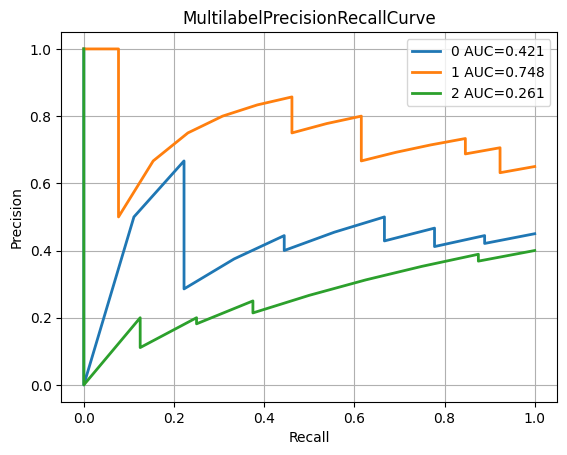

In [75]:
from torch import rand, randint
from torchmetrics.classification import MultilabelPrecisionRecallCurve
preds = rand(20, 3)
target = randint(2, (20,3))
metric = MultilabelPrecisionRecallCurve(num_labels=3)
metric.update(preds, target)
fig_, ax_ = metric.plot(score=True)
plt.show()

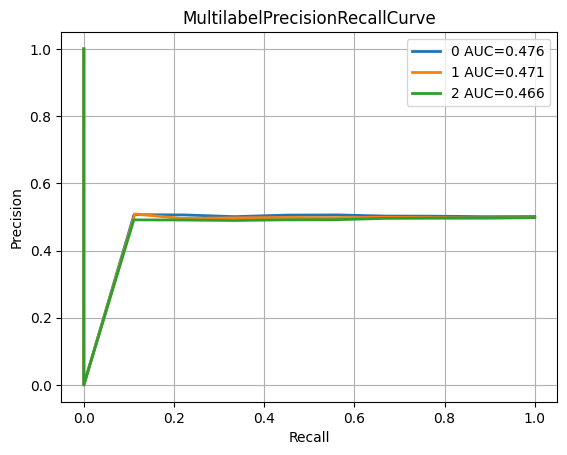

In [99]:
metric.reset()
metric.update(preds[32], targets[32])
metric.plot(score=True)
plt.show()
metric.reset()

In [90]:
patch_classify_metrics = MultiLabelPatchClassifyMetrics(metrics_names=['cm', 'f1', 'ap', 'pr_curve', 'ppv', 'tpr'],patch_sizes=[8, 32, 16], labels=['ED', 'ET', 'NCR'], threshold=0.5)
_print('multilabel_patch_classify_metrics', patch_classify_metrics)

------------------------------
multilabel_patch_classify_metrics
------------------------------
MultiLabelPatchClassifyMetrics(
  (metrics): MultitaskWrapper(
    (task_metrics): ModuleDict(
      (8): MetricCollection(
        (ap): ClasswiseWrapper(
          (metric): MultilabelAveragePrecision()
        )
        (cm): MultilabelConfusionMatrix()
        (f1): ClasswiseWrapper(
          (metric): MultilabelF1Score()
        )
        (ppv): ClasswiseWrapper(
          (metric): MultilabelPrecision()
        )
        (pr_curve): MultilabelPrecisionRecallCurve()
        (tpr): ClasswiseWrapper(
          (metric): MultilabelRecall()
        )
      )
      (16): MetricCollection(
        (ap): ClasswiseWrapper(
          (metric): MultilabelAveragePrecision()
        )
        (cm): MultilabelConfusionMatrix()
        (f1): ClasswiseWrapper(
          (metric): MultilabelF1Score()
        )
        (ppv): ClasswiseWrapper(
          (metric): MultilabelPrecision()
        )
       

In [91]:
start_time = time.time()
out = patch_classify_metrics(preds, targets)
patch_classify_metrics.reset() #always reset if metric needs to be ready for new data
_print('main_metrics:', out['main_metrics'])
_print('other_metrics:', out['other_metrics'])
print('Forward took ', time.time()-start_time)

------------------------------
main_metrics:
------------------------------
{'patch_classify_multilabel_ap_res=8': tensor(0.5001),
 'patch_classify_multilabel_ap_res=16': tensor(0.5002),
 'patch_classify_multilabel_ap_res=32': tensor(0.4986),
 'patch_classify_multilabel_ap_mean': tensor(0.4996),
 'patch_classify_multilabel_ap_ED_res=8': tensor(0.5007),
 'patch_classify_multilabel_ap_ED_res=16': tensor(0.5019),
 'patch_classify_multilabel_ap_ED_res=32': tensor(0.5035),
 'patch_classify_multilabel_ap_ED_mean': tensor(0.5020),
 'patch_classify_multilabel_ap_ET_res=8': tensor(0.4999),
 'patch_classify_multilabel_ap_ET_res=16': tensor(0.4990),
 'patch_classify_multilabel_ap_ET_res=32': tensor(0.4988),
 'patch_classify_multilabel_ap_ET_mean': tensor(0.4992),
 'patch_classify_multilabel_ap_NCR_res=8': tensor(0.4996),
 'patch_classify_multilabel_ap_NCR_res=16': tensor(0.4997),
 'patch_classify_multilabel_ap_NCR_res=32': tensor(0.4934),
 'patch_classify_multilabel_ap_NCR_mean': tensor(0.4976),


In [92]:
start_time = time.time()
patch_classify_metrics.update(preds, targets)
out = patch_classify_metrics.compute()
_print('main_metrics:', out['main_metrics'])
_print('other_metrics:', out['other_metrics'])
#patch_classify_metrics.reset() #always reset if metric needs to be ready for new data
print('Update and compute took ', time.time()-start_time)

------------------------------
main_metrics:
------------------------------
{'patch_classify_multilabel_ap_res=8': tensor(0.5001),
 'patch_classify_multilabel_ap_res=16': tensor(0.5002),
 'patch_classify_multilabel_ap_res=32': tensor(0.4986),
 'patch_classify_multilabel_ap_mean': tensor(0.4996),
 'patch_classify_multilabel_ap_ED_res=8': tensor(0.5007),
 'patch_classify_multilabel_ap_ED_res=16': tensor(0.5019),
 'patch_classify_multilabel_ap_ED_res=32': tensor(0.5035),
 'patch_classify_multilabel_ap_ED_mean': tensor(0.5020),
 'patch_classify_multilabel_ap_ET_res=8': tensor(0.4999),
 'patch_classify_multilabel_ap_ET_res=16': tensor(0.4990),
 'patch_classify_multilabel_ap_ET_res=32': tensor(0.4988),
 'patch_classify_multilabel_ap_ET_mean': tensor(0.4992),
 'patch_classify_multilabel_ap_NCR_res=8': tensor(0.4996),
 'patch_classify_multilabel_ap_NCR_res=16': tensor(0.4997),
 'patch_classify_multilabel_ap_NCR_res=32': tensor(0.4934),
 'patch_classify_multilabel_ap_NCR_mean': tensor(0.4976),


/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric MultilabelPrecision was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)  # noqa: B028
/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of metric MultilabelRecall was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)  # noqa: B028


In [56]:
from matplotlib import pyplot as plt

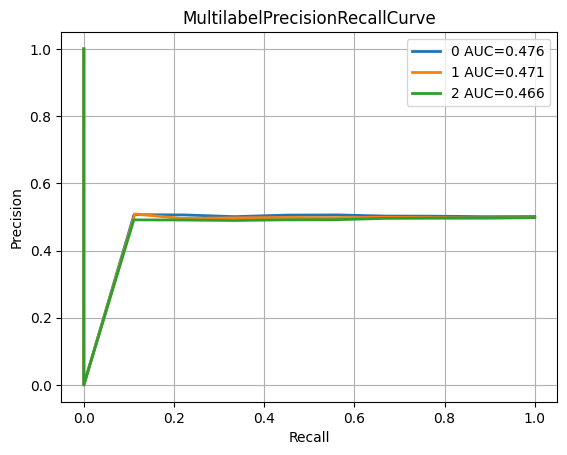

In [100]:
fig, ax = patch_classify_metrics.metrics.task_metrics['32']['pr_curve'].plot(score=True)
plt.show()

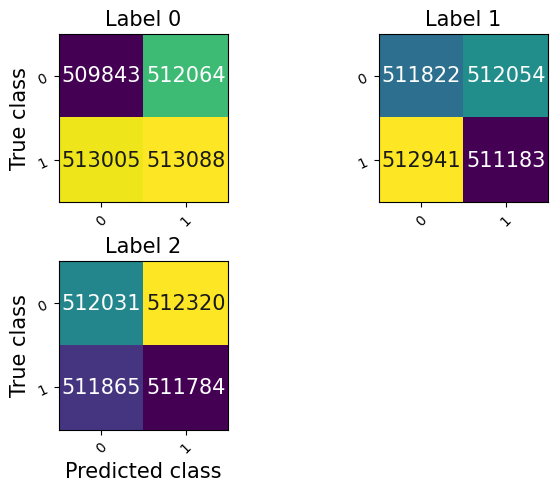

In [103]:
fig, ax = patch_classify_metrics.metrics.task_metrics['8']['cm'].plot()
plt.show()

#### Apply metrics over entire data iteratively (batch-by-batch), and aggregate at end

In [38]:
preds, targets = create_patch_classify_preds_and_target(n_channels=3, batch_size=100)
print('preds', {k:v.shape for k,v in preds.items()})
print('targets', {k:v.shape for k,v in targets.items()})

preds {8: torch.Size([100, 3, 16, 16, 16]), 16: torch.Size([100, 3, 8, 8, 8]), 32: torch.Size([100, 3, 4, 4, 4])}
targets {8: torch.Size([100, 3, 16, 16, 16]), 16: torch.Size([100, 3, 8, 8, 8]), 32: torch.Size([100, 3, 4, 4, 4])}


In [70]:
patch_classify_metrics = MultiLabelPatchClassifyMetrics(metrics_names=['f1', 'precision', 'recall', 'ba', 'cm', 'ppv', 'tpr'],patch_sizes=[8, 32, 16], labels=['ED', 'ET', 'NCR'], threshold=0.5)
_print('multilabel_patch_classify_metrics', patch_classify_metrics)

------------------------------
multilabel_patch_classify_metrics
------------------------------
MultiLabelPatchClassifyMetrics(
  (metrics): MultitaskWrapper(
    (task_metrics): ModuleDict(
      (8): MetricCollection(
        (ba): ClasswiseWrapper(
          (metric): CompositionalMetric(
            mul(
              0.5,
              CompositionalMetric(
            add(
              MultilabelRecall(),
              MultilabelSpecificity()
            )
          )
            )
          )
        )
        (cm): MultilabelConfusionMatrix()
        (f1): ClasswiseWrapper(
          (metric): MultilabelF1Score()
        )
        (ppv): ClasswiseWrapper(
          (metric): MultilabelPrecision()
        )
        (precision): ClasswiseWrapper(
          (metric): MultilabelPrecision()
        )
        (recall): ClasswiseWrapper(
          (metric): MultilabelRecall()
        )
        (tpr): ClasswiseWrapper(
          (metric): MultilabelRecall()
        )
      )
      (16)

In [46]:
start_time = time.time()
patch_sizes = [8, 16, 32]
print('Computing Classify metrics on the entire dataset iteratively, acculmulating batch-by-batch.....')
batch_size = 10
data_size = 500
for i in range(data_size//batch_size):
    preds_ = {}
    targets_ = {}
    for key in patch_sizes:
        pred = preds[key][i*batch_size:((i+1)*batch_size)]
        target = targets[key][i*batch_size:((i+1)*batch_size)]
        preds_[key] = pred
        targets_[key] = target
    patch_classify_metrics.update(preds_, targets_)
all_metrics = patch_classify_metrics.compute()
patch_classify_metrics.reset() #always reset if metric needs to be ready for new data
_print('patch_classify: main_metrics', all_metrics['main_metrics'])
_print('patch_classify: other_metrics', all_metrics['other_metrics'])
print('Batch-by-batch took ', time.time()-start_time)

Computing Classify metrics on the entire dataset iteratively, acculmulating batch-by-batch.....
------------------------------
patch_classify: main_metrics
------------------------------
{'patch_classify_multilabel_ap_res=8': tensor(0.8426),
 'patch_classify_multilabel_ap_res=16': tensor(0.7177),
 'patch_classify_multilabel_ap_res=32': tensor(0.6117),
 'patch_classify_multilabel_ap_mean': tensor(0.7240),
 'patch_classify_multilabel_ap_ED_res=8': tensor(0.8422),
 'patch_classify_multilabel_ap_ED_res=16': tensor(0.7168),
 'patch_classify_multilabel_ap_ED_res=32': tensor(0.6095),
 'patch_classify_multilabel_ap_ED_mean': tensor(0.7228),
 'patch_classify_multilabel_ap_ET_res=8': tensor(0.8428),
 'patch_classify_multilabel_ap_ET_res=16': tensor(0.7182),
 'patch_classify_multilabel_ap_ET_res=32': tensor(0.6144),
 'patch_classify_multilabel_ap_ET_mean': tensor(0.7251),
 'patch_classify_multilabel_ap_NCR_res=8': tensor(0.8428),
 'patch_classify_multilabel_ap_NCR_res=16': tensor(0.7180),
 'patch

In [69]:
patch_classify_metrics.metrics.task_metrics['16'].compute_groups

{0: ['cm'], 1: ['f1'], 2: ['ap', 'pr_curve']}